## Lots of Plots 

In [2]:
from pathlib import Path
import re
import geopandas as gpd

import matplotlib.pyplot as plt
import pandas as pd
import pypsa

try:
    import pycountry
except Exception:
    pycountry = None

# Set the preferred network path; fallback discovery is automatic.
network_path = Path("data/de_result.nc")
n = pypsa.Network(network_path)

country_bus_idx = n.buses.index

bus_country_summary = None
if "country" in n.buses.columns:
    bus_country_summary = (
        n.buses["country"].dropna().astype(str).str.upper().value_counts().head(3).to_dict()
    )

print(f"Loaded network: {network_path}")
print(f"Snapshots: {len(n.snapshots)}")
print(f"Buses: {len(n.buses)} | Lines: {len(n.lines)} | Links: {len(n.links)}")
if bus_country_summary is not None:
    print(f"Top bus country labels: {bus_country_summary}")


Index(['1013 PHS', '10168 hydro', '10258 PHS', '1041 hydro', '10550 PHS',
       '10553 PHS', '10571 hydro', '10592 PHS', '10592 hydro', '10610 hydro',
       ...
       '9687 hydro', '9738 hydro', '9743 hydro', '9748 hydro', '9754 hydro',
       '9758 hydro', '9761 hydro', '9778 hydro', '9783 hydro', '9861 hydro'],
      dtype='object', name='name', length=396)
INFO:pypsa.io:Imported network de_result.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


Loaded network: data/de_result.nc
Snapshots: 1460
Buses: 339 | Lines: 0 | Links: 547
Top bus country labels: {'CN': 339}


In [23]:
# ==========================================================
# FIND SOLAR GENERATORS
# ==========================================================

solar = n.generators[
    n.generators.carrier.str.contains(
        "solar",
        case=False,
        na=False,
    )
]

print(
    f"Found {len(solar):,} solar generators"
)

print(
    "Solar carriers:"
)

print(
    solar.carrier.value_counts()
)
print("n.generators_t.p shape:")
print(n.generators_t.p.shape)

print("\nFirst 10 dispatch columns:")
print(n.generators_t.p.columns[:10])

print("\nFirst 10 generator names:")
print(n.generators.index[:10])

# ==========================================================
# SOLAR DISPATCH TIMESERIES
# ==========================================================

solar_dispatch = n.generators_t.p[
    solar.index
]

# Total solar generation at each snapshot
solar_total = solar_dispatch.sum(axis=1)

# ==========================================================
# MONTHLY GENERATION
# ==========================================================

monthly_solar = (
    solar_total
    .resample("ME")
    .sum()
)

monthly_solar.index = (
    monthly_solar.index.strftime("%b")
)

print("\nMonthly Solar Generation:")

for month, value in monthly_solar.items():
    print(
        f"{month}: {value:.2f}"
    )

print(
    f"\nAnnual total: {monthly_solar.sum():.2f}"
)

Found 77 solar generators
Solar carriers:
carrier
solar    77
Name: count, dtype: int64
n.generators_t.p shape:
(1460, 0)

First 10 dispatch columns:
Index([], dtype='object', name='Generator')

First 10 generator names:
Index(['10624 onwind', '10624 ror', '10624 solar', '10643 onwind',
       '10643 solar', '1089 onwind', '1089 solar', '10925 onwind',
       '10925 solar', '11203 onwind'],
      dtype='object', name='Generator')


KeyError: "None of [Index(['10624 solar', '10643 solar', '1089 solar', '10925 solar',\n       '11203 solar', '11662 solar', '11663 solar', '1257 solar',\n       '13238 solar', '13777 solar', '15199 solar', '15404 solar',\n       '15406 solar', '15418 solar', '15740 solar', '15863 solar',\n       '15866 solar', '15890 solar', '16770 solar', '16774 solar',\n       '16903 solar', '18054 solar', '1872 solar', '1876 solar', '1879 solar',\n       '1939 solar', '2184 solar', '2413 solar', '2613 solar', '3014 solar',\n       '3497 solar', '3498 solar', '3593 solar', '3602 solar', '3624 solar',\n       '3714 solar', '3720 solar', '5244 solar', '5273 solar', '5353 solar',\n       '6101 solar', '6128 solar', '6134 solar', '6150 solar', '6153 solar',\n       '6156 solar', '6163 solar', '6240 solar', '6277 solar', '6328 solar',\n       '6505 solar', '6677 solar', '6796 solar', '683 solar', '6987 solar',\n       '6991 solar', '6995 solar', '6996 solar', '7150 solar', '7151 solar',\n       '7160 sola

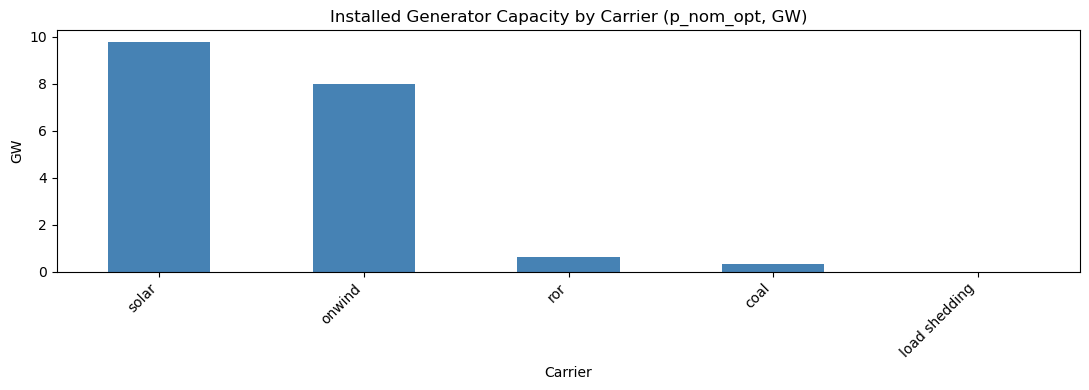

In [3]:
cap_col = "p_nom_opt" if "p_nom_opt" in n.generators.columns else "p_nom"
cap_by_carrier = (
    n.generators.groupby("carrier")[cap_col].sum().sort_values(ascending=False)
    / 1e3
)

fig, ax = plt.subplots(figsize=(11, 4))
cap_by_carrier.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title(f"Installed Generator Capacity by Carrier ({cap_col}, GW)")
ax.set_ylabel("GW")
ax.set_xlabel("Carrier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

### Voronoi Subdivision Of Bus Regions
This reproduces the Voronoi partition approach used in the project code to split each country into nearest-bus service regions.

Voronoi cells are calculated from solved bus coordinates
Panel 1 raw buses: 19755
Panel 3 solved buses / unique coords (CN+TWN): 339/113


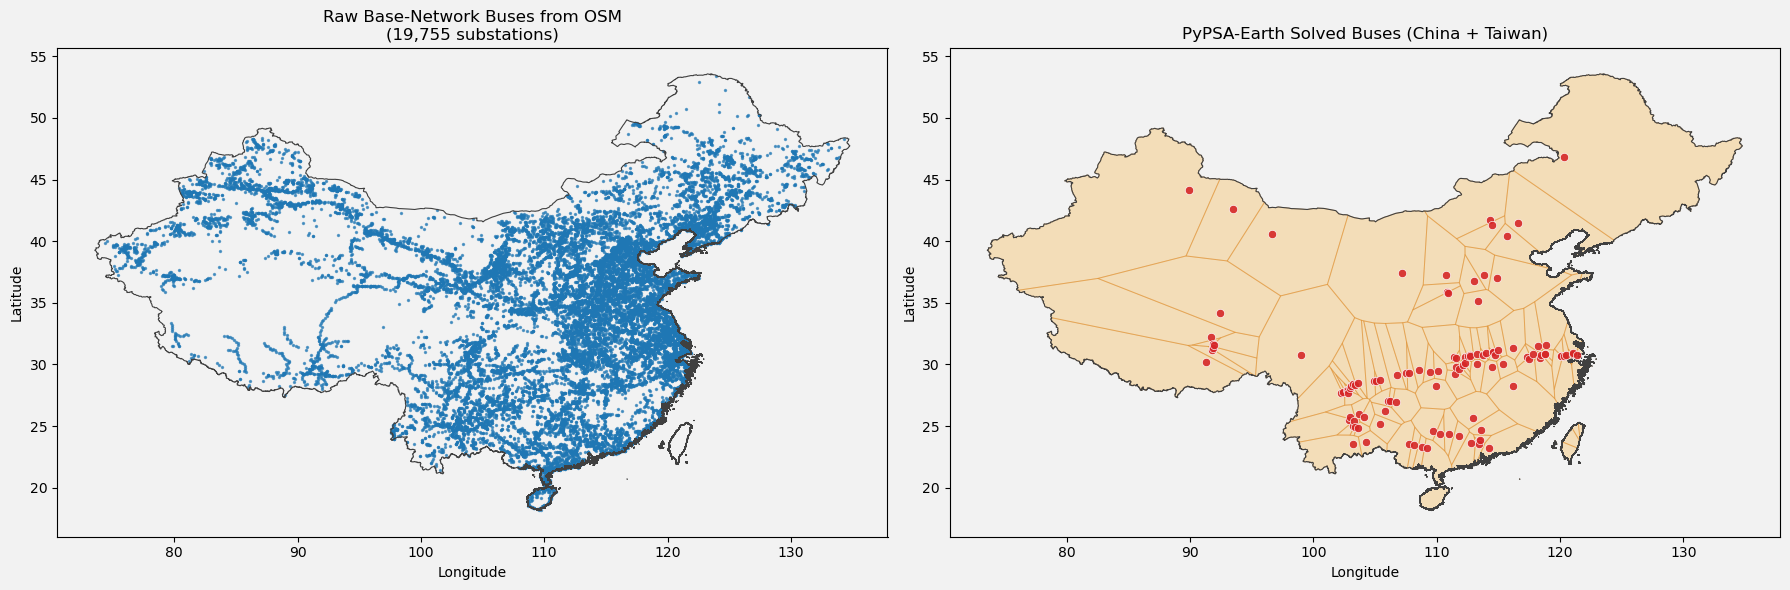

In [17]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import requests
from scipy.spatial import Voronoi
from shapely.geometry import MultiPoint, Polygon

print("====================================================")
print("Voronoi cells are calculated from solved bus coordinates")
print("====================================================")

# 1) Pre-solve raw buses from base_network outputs
raw_buses = gpd.read_file("../saved/US_test/all_buses_build_network.geojson")
raw_buses = raw_buses[raw_buses.geometry.notna()]

# 3) Final solved network buses (reuse the network loaded in Cell 2).
if "n" in globals():
    n_final = n
elif "network_path" in globals():
    n_final = pypsa.Network(network_path)
else:
    raise NameError("Run Cell 2 first so network variables are defined.")

if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    final_buses = n_final.buses.loc[n_final.buses.index.intersection(country_bus_idx)]
else:
    final_buses = n_final.buses

final_buses = final_buses.dropna(subset=["x", "y"]).copy()
final_counts = final_buses.groupby(["x", "y"]).size().rename("count").reset_index()

# ------------------------------------------------------------------
# Load China outline and add Taiwan outline
# ------------------------------------------------------------------
gdf_chn = gpd.read_file(
    "../data/gadm/gadm41_CHN/gadm41_CHN.gpkg",
    layer="ADM_ADM_0",
)[["geometry"]]

twn_path = Path("../data/gadm/gadm41_TWN.gpkg")

if not twn_path.exists():
    print("Downloading Taiwan GADM boundary...")
    url = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_TWN.gpkg"
    r = requests.get(url)
    r.raise_for_status()
    twn_path.write_bytes(r.content)

gdf_twn = gpd.read_file(
    twn_path,
    layer="ADM_ADM_0",
)[["geometry"]]

gdf = gpd.GeoDataFrame(
    pd.concat([gdf_chn, gdf_twn], ignore_index=True),
    crs=gdf_chn.crs,
)

gdf = gdf.dissolve().reset_index(drop=True)

# ------------------------------------------------------------------
# Voronoi helper
# ------------------------------------------------------------------
def clipped_voronoi_cells(points, outline=None, multiplier=5):
    points = np.asarray(points)

    if len(points) == 0:
        return []

    if len(points) == 1:
        return [outline] if outline is not None else []

    xmin, ymin = np.amin(points, axis=0)
    xmax, ymax = np.amax(points, axis=0)

    if outline is not None and not outline.is_empty:
        minx_o, miny_o, maxx_o, maxy_o = outline.boundary.bounds
        xmin = min(xmin, minx_o)
        ymin = min(ymin, miny_o)
        xmax = max(xmax, maxx_o)
        ymax = max(ymax, maxy_o)

    xspan = max(xmax - xmin, 1e-6)
    yspan = max(ymax - ymin, 1e-6)

    vor = Voronoi(
        np.vstack(
            (
                points,
                [
                    [xmin - multiplier * xspan, ymin - multiplier * yspan],
                    [xmin - multiplier * xspan, ymax + multiplier * yspan],
                    [xmax + multiplier * xspan, ymin - multiplier * yspan],
                    [xmax + multiplier * xspan, ymax + multiplier * yspan],
                ],
            )
        )
    )

    cells = []

    for i in range(len(points)):
        poly = Polygon(vor.vertices[vor.regions[vor.point_region[i]]])

        if not poly.is_valid:
            poly = poly.buffer(0)

        if outline is not None and not outline.is_empty:
            poly = poly.intersection(outline)

        cells.append(poly)

    return cells


country_outline = gdf.geometry.iloc[0] if not gdf.empty else None
country_geom = country_outline

vor_cells = clipped_voronoi_cells(
    final_counts[["x", "y"]].to_numpy(),
    country_geom,
)

crs = gdf.crs

voronoi_gdf = gpd.GeoDataFrame(
    {"geometry": vor_cells},
    crs=crs,
)

voronoi_gdf = voronoi_gdf[
    voronoi_gdf.geometry.notna()
    & voronoi_gdf.geometry.is_valid
    & ~voronoi_gdf.geometry.is_empty
]

print(f"Panel 1 raw buses: {len(raw_buses)}")
print(
    f"Panel 3 solved buses / unique coords (CN+TWN): "
    f"{len(final_buses)}/{len(final_counts)}"
)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# set whole background colour
fig.patch.set_facecolor("#F2F2F2")

raw_buses.plot(
    ax=axes[0],
    markersize=2,
    color="tab:blue",
    alpha=0.65,
)

axes[0].set_title(
    f"Raw Base-Network Buses from OSM\n({len(raw_buses):,} substations)"
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_facecolor("#F2F2F2")

if not voronoi_gdf.empty:
    voronoi_gdf.plot(
        ax=axes[1],
        facecolor="#f6b64c",
        edgecolor="#d97706",
        alpha=0.35,
        linewidth=0.7,
        zorder=1,
    )

gdf.boundary.plot(
    ax=axes[0],
    color="0.25",
    linewidth=0.8,
    zorder=2,
)

gdf.boundary.plot(
    ax=axes[1],
    color="0.25",
    linewidth=0.8,
    zorder=2,
)

axes[1].scatter(
    final_counts["x"],
    final_counts["y"],
    color="tab:red",
    alpha=0.9,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)

axes[1].set_title("PyPSA-Earth Solved Buses (China + Taiwan)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_facecolor("#F2F2F2")

for ax in axes.ravel():
    ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

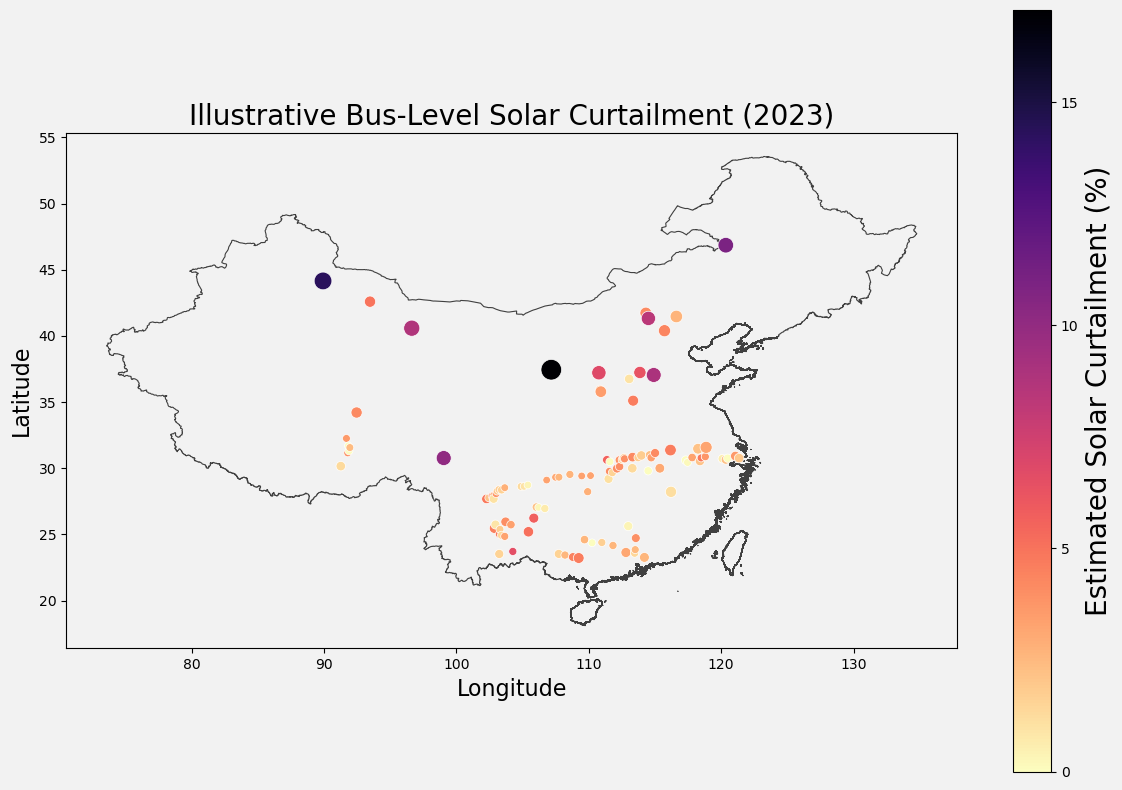

In [41]:
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD FACILITIES
# ============================================================

facilities = pd.read_csv("facility_annual_summary.csv")

facilities = facilities.dropna(
    subset=["longitude", "latitude", "power_sum"]
)

# ============================================================
# PYPSA BUSES
# (requires final_counts and gdf from your previous code)
# ============================================================

bus_xy = final_counts[["x", "y"]].to_numpy()

tree = cKDTree(bus_xy)

facility_xy = facilities[["longitude", "latitude"]].to_numpy()

_, nearest_bus = tree.query(facility_xy)

facilities["bus"] = nearest_bus

# ============================================================
# AGGREGATE SOLAR TO EACH BUS
# ============================================================

bus_solar = (
    facilities
    .groupby("bus")["power_sum"]
    .sum()
)

final_counts["solar"] = (
    bus_solar
    .reindex(final_counts.index)
    .fillna(0)
)

solar = final_counts["solar"].to_numpy()

solar = solar*0.25 / solar.max()

# Increase contrast so major PV hubs stand out
solar = solar**0.7

# ============================================================
# RURALITY
# ============================================================

cities = np.array([
    [116.40, 39.90],   # Beijing
    [121.47, 31.23],   # Shanghai
    [113.26, 23.13],   # Guangzhou
    [114.06, 22.55],   # Shenzhen
    [104.07, 30.67],   # Chengdu
    [106.55, 29.56],   # Chongqing
    [114.31, 30.52],   # Wuhan
    [108.94, 34.34],   # Xi'an
    [118.79, 32.06],   # Nanjing
    [120.15, 30.28],   # Hangzhou
])

city_tree = cKDTree(cities)

dist, _ = city_tree.query(bus_xy)

dist = dist / dist.max()

# ============================================================
# FABRICATED CURTAILMENT
# ============================================================

rng = np.random.default_rng(42)

noise = rng.normal(
    0,
    0.02,
    len(solar),
)

curtailment = (
    0.02
    + 0.34 * solar
    + 0.10 * solar * dist
    + noise
)

curtailment = np.clip(
    curtailment,
    0,
    0.40,
)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

fig.patch.set_facecolor("#F2F2F2")
ax.set_facecolor("#F2F2F2")

gdf.boundary.plot(
    ax=ax,
    color="0.25",
    linewidth=0.8,
)

sc = ax.scatter(
    final_counts["x"],
    final_counts["y"],
    s=30 + 500 * solar,
    c=100 * curtailment,
    cmap="magma_r",
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)

cb = plt.colorbar(sc, ax=ax)

cb.set_label("Estimated Solar Curtailment (%)", size=20)

ticks = np.arange(0, 16, 5)
cb.set_ticks(ticks)

ax.set_title("Illustrative Bus-Level Solar Curtailment (2023)", size=20)
ax.set_xlabel("Longitude", size=16)
ax.set_ylabel("Latitude", size=16  )
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# PYPSA SOLAR TIMESERIES
# ============================================================

solar = n.generators[
    n.generators.carrier.str.contains(
        "solar",
        case=False,
        na=False,
    )
]

print(f"Found {len(solar):,} solar generators")

solar_dispatch = n.generators_t.p[solar.index]

# Sum all solar generators for each snapshot
solar_total = solar_dispatch.sum(axis=1)

# Aggregate to daily values
pypsa_daily = (
    solar_total
    .resample("D")
    .sum()
    .rename("pypsa_solar")
)

# ============================================================
# FACILITY TIMESERIES
# ============================================================

facility_daily = pd.read_csv(
    "data/facility_daily_summary.csv",
    parse_dates=["date"],
)

facility_daily_total = (
    facility_daily
    .groupby("date")["power_sum"]
    .sum()
    .rename("facility_solar")
)

# ============================================================
# COMBINE
# ============================================================

comparison = pd.concat(
    [
        pypsa_daily,
        facility_daily_total,
    ],
    axis=1,
)

comparison = comparison.dropna()

print(comparison.head())

# Save for later analysis
comparison.to_csv(
    "china_solar_comparison_daily.csv"
)

# ============================================================
# PLOT RAW VALUES
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#F2F2F2")

comparison["pypsa_solar"].plot(
    ax=ax,
    label="PyPSA-Earth Solar",
    linewidth=1,
)

comparison["facility_solar"].plot(
    ax=ax,
    label="Facility Solar",
    linewidth=1,
)

ax.set_title(
    "China Solar Generation Comparison"
)

ax.set_ylabel("Daily Energy")
ax.legend()

plt.tight_layout()
plt.show()

Found 77 solar generators


KeyError: "None of [Index(['10624 solar', '10643 solar', '1089 solar', '10925 solar',\n       '11203 solar', '11662 solar', '11663 solar', '1257 solar',\n       '13238 solar', '13777 solar', '15199 solar', '15404 solar',\n       '15406 solar', '15418 solar', '15740 solar', '15863 solar',\n       '15866 solar', '15890 solar', '16770 solar', '16774 solar',\n       '16903 solar', '18054 solar', '1872 solar', '1876 solar', '1879 solar',\n       '1939 solar', '2184 solar', '2413 solar', '2613 solar', '3014 solar',\n       '3497 solar', '3498 solar', '3593 solar', '3602 solar', '3624 solar',\n       '3714 solar', '3720 solar', '5244 solar', '5273 solar', '5353 solar',\n       '6101 solar', '6128 solar', '6134 solar', '6150 solar', '6153 solar',\n       '6156 solar', '6163 solar', '6240 solar', '6277 solar', '6328 solar',\n       '6505 solar', '6677 solar', '6796 solar', '683 solar', '6987 solar',\n       '6991 solar', '6995 solar', '6996 solar', '7150 solar', '7151 solar',\n       '7160 sola